In [52]:
import importlib, subprocess, sys
for pkg in ["pyarrow", "openpyxl"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)

# Paleta de figuras: 4 hues categóricos (uno por paso) + diverging azul-gris-rojo.
# Orden fijo, nunca ciclado; las líneas van rotuladas para no depender solo del color.
COLOR_PASO = {"P1": "#2a78d6", "P2": "#eb6834", "P3": "#1baf7a", "P4": "#eda100"}
SUP, TINTA, TINTA2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
CMAP_DIV = LinearSegmentedColormap.from_list(
    "div", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#e8a3a3", "#d03b3b", "#7d1f1f"])
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "figure.facecolor": SUP, "axes.facecolor": SUP,
    "text.color": TINTA, "axes.labelcolor": TINTA2, "xtick.color": TINTA2,
    "ytick.color": TINTA2, "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.1


In [53]:
from pathlib import Path

BASE     = Path.cwd()
DATA     = BASE / "data"
FEATURES = BASE / "features"
REPORTES = BASE / "reportes"
for d in (DATA, FEATURES, REPORTES):
    d.mkdir(parents=True, exist_ok=True)

XLSX      = DATA / "Dataset_T°C_B-3001.xlsx"
OUT_LARGO = FEATURES / "b3001_largo.parquet"       # Nivel 3-4: el despivot crudo

assert XLSX.exists() or CACHE_VAL.exists(), f"Falta {XLSX} y no hay caché en {DATA}."
print("Proyecto:", BASE)

Proyecto: /Users/bencourtin/Developer/projects/Tesis_HornoB3001


In [54]:
# ---------- limpieza, estado de operación y validez de sensor ----------
SAT_LIMITE   = 700.0     # >700 °C = clamp del historiador, no es medición
T_MIN_TUBO   = 300.0     # con el horno encendido, un tubo por debajo de esto = sensor fallado
RUN_TH       = 250.0     # mediana CONV >= 250 °C -> operación
STOP_TH      = 150.0     # mediana CONV <  150 °C -> detención fría
GAP_CIERRE_H = 6         # huecos <=6 h dentro de un STOP se cierran
MERGE_H      = 24        # detenciones separadas <24 h se fusionan
MIN_STOP_H   = 4         # mínimo de horas frías reales para contar el episodio
W_FLAT, TOL_FLAT = 12, 0.05   # std móvil 12 h < 0.05 °C -> lectura congelada

# ---------- creep: material T9, API 530 ----------
CLM               = 20.946
TMT_DISENO        = 705.0
DO, T_PROM        = 108.0, 12.1
P_MPA             = 57.2 * 0.0981
VIDA_DISENO_H     = 100_000.0
SIGMA_H   = (P_MPA * (DO - T_PROM)) / (2 * T_PROM)
LMP_SIGMA = (TMT_DISENO + 273.15) * (CLM + np.log10(VIDA_DISENO_H)) / 1000

# ---------- umbrales y ventanas de las features ----------
T_HOT     = 650.0        # tubo caliente. ~P95 de las lecturas en operación
W_SLOPE   = 6            # ventana de la pendiente corta (h)
W_DIA     = 24
W_MES     = 24 * 30
MIN_TUBOS = 3            # mínimo de tubos válidos para agregar un paso
H_TARGET  = 24           # horizonte de predicción (h)

# ---------- mapeo tag -> (paso, punto) ----------
MAPPING = {
 "TI_30021.pv":("P1","CONV"),
 "TI_30017A.pv":("P1","T1 SP"), "TI_30017D.pv":("P1","T1 SO"),
 "TI_30017B.pv":("P1","T5 SP"), "TI_30017E.pv":("P1","T5 SO"),
 "TI_30017C.pv":("P1","T10 NP"),"TI_30017F.pv":("P1","T10 NO"),
 "TI_30022.pv":("P2","CONV"),
 "TI_30018A.pv":("P2","T1 NP"), "TI_30018D.pv":("P2","T1 NO"),
 "TI_30018B.pv":("P2","T5 NP"), "TI_30018E.pv":("P2","T5 NO"),
 "TI_30018C.pv":("P2","T10 SP"),"TI_30018F.pv":("P2","T10 SO"),
 "TI_30033.pv":("P3","CONV"),
 "TI_30031A.pv":("P3","T1 SP"), "TI_30031D.pv":("P3","T1 SO"),
 "TI_30031B.pv":("P3","T5 SP"), "TI_30031E.pv":("P3","T5 SO"),
 "TI_30031C.pv":("P3","T10 NP"),"TI_30031F.pv":("P3","T10 NO"),
 "TI_30034.pv":("P4","CONV"),
 "TI_30032A.pv":("P4","T1 NP"), "TI_30032D.pv":("P4","T1 NO"),
 "TI_30032B.pv":("P4","T5 NP"), "TI_30032E.pv":("P4","T5 NO"),
 "TI_30032C.pv":("P4","T10 SP"),"TI_30032F.pv":("P4","T10 SO"),
 "TC_30028.pv":("CTRL","P4"), "TC_30027.pv":("CTRL","P3"),
 "TC_30020.pv":("CTRL","P2"), "TC_30019.pv":("CTRL","P1"),
}
HORNO = "B-3001"
PASOS = ["P1", "P2", "P3", "P4"]
TAGS  = list(MAPPING)
CONV  = {p: [c for c,(pp,n) in MAPPING.items() if pp==p and n=="CONV"][0] for p in PASOS}
CTRL  = {v[1]: k for k,v in MAPPING.items() if v[0]=="CTRL"}

# tag -> tubo "17A" / paso / elevación / cara
TAG2TUBO, TUBO_PASO, TUBO_ELEV, TUBO_CARA = {}, {}, {}, {}
for tag, (p, n) in MAPPING.items():
    if p == "CTRL" or n == "CONV":
        continue
    t = f"{tag[6:8]}{tag[8]}"                 # TI_30017A.pv -> "17A"
    elev, cara = n.split()                    # "T1 SP" -> ("T1", "SP")
    TAG2TUBO[tag] = t
    TUBO_PASO[t], TUBO_ELEV[t], TUBO_CARA[t] = p, elev, cara

TUBO_TAGS  = list(TAG2TUBO)
TUBOS      = sorted(TAG2TUBO.values())
TUBOS_PASO = {p: [t for t in TUBOS if TUBO_PASO[t] == p] for p in PASOS}

# ---------- ventana de análisis ----------
# Todo se calcula sobre el histórico completo (las acumuladas de creep y las ventanas de 30 d
# necesitan el pasado); el recorte a DATA_START se aplica recién en la celda 11.
DATA_START = pd.Timestamp("2024-10-01")
DATA_END   = None

print(f"sigma_h = {SIGMA_H:.2f} MPa | LMP_sigma = {LMP_SIGMA:.4f}")
for p in PASOS:
    print(f"  {p}: {TUBOS_PASO[p]}")
print(f"Jerarquía: 1 horno · {len(PASOS)} pasos · {len(TUBOS)} tubos")
print(f"Ventana: {DATA_START.date()} -> {DATA_END.date() if DATA_END is not None else 'último dato'}")

sigma_h = 22.24 MPa | LMP_sigma = 25.3791
  P1: ['17A', '17B', '17C', '17D', '17E', '17F']
  P2: ['18A', '18B', '18C', '18D', '18E', '18F']
  P3: ['31A', '31B', '31C', '31D', '31E', '31F']
  P4: ['32A', '32B', '32C', '32D', '32E', '32F']
Jerarquía: 1 horno · 4 pasos · 24 tubos
Ventana: 2024-10-01 -> último dato


In [55]:
df_test = pd.read_parquet(FEATURES / "b3001_largo.parquet")
df_test = df_test[df_test["ts"] >= DATA_START]
df_test

,horno,ts,fecha,hora,paso,tubo,elev,cara,temperatura,valido,run,sat,sensor_frio,sensor_flat,h_desde_arranque
3433752,B-3001,2024-10-01 00:00:00,2024-10-01,0,P1,17A,T1,SP,494.277100,1,1,0,0,0,5721
3433753,B-3001,2024-10-01 00:00:00,2024-10-01,0,P1,17B,T5,SP,NaN,0,1,0,0,0,5721
3433754,B-3001,2024-10-01 00:00:00,2024-10-01,0,P1,17C,T10,NP,491.481628,1,1,0,0,0,5721
3433755,B-3001,2024-10-01 00:00:00,2024-10-01,0,P1,17D,T1,SO,569.479797,1,1,0,0,0,5721
3433756,B-3001,2024-10-01 00:00:00,2024-10-01,0,P1,17E,T5,SO,562.342102,1,1,0,0,0,5721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714043,B-3001,2026-01-30 14:00:00,2026-01-30,14,P4,32B,T5,NP,645.991821,1,1,0,0,0,121
3714044,B-3001,2026-01-30 14:00:00,2026-01-30,14,P4,32C,T10,SP,NaN,0,1,1,0,0,121
3714045,B-3001,2026-01-30 14:00:00,2026-01-30,14,P4,32D,T1,NO,596.670166,1,1,0,0,0,121
3714046,B-3001,2026-01-30 14:00:00,2026-01-30,14,P4,32E,T5,NO,NaN,0,1,0,0,0,121


## 1. Detenciones del horno

Se reconstruye el estado operativo horario del horno a partir de `run` (ya calculado
en el despivot: mediana de los `CONV` de los 4 pasos >= `RUN_TH`). `run` es el mismo
para los 24 tubos en un mismo `ts`, así que basta una serie a nivel horno. Sobre esa
serie se aplican los mismos criterios de limpieza de episodios que en el resto del
pipeline: huecos cortos (`<= GAP_CIERRE_H`) se cierran, detenciones separadas por
`< MERGE_H` horas se fusionan (rearranques fallidos) y solo cuentan las que acumulan
`>= MIN_STOP_H` horas frías reales.

El gráfico muestra la temperatura mediana por paso (`ts` en el eje X, TMT en el eje
Y) en vez de un simple indicador binario: así se ve el comportamiento térmico real
alrededor de cada detención (la caída de temperatura al parar, la rampa de
recuperación al reencender). Se comparan tres ventanas: 2020-10-01 → 2024-10-01,
`DATA_START` → actualidad, y el periodo completo del dataset.

In [56]:
df = pd.read_parquet(FEATURES / "b3001_largo.parquet")   # histórico completo: el creep (celda 4) lo necesita

# estado horario a nivel horno (run es idéntico para los 24 tubos en un mismo ts)
horno_ts = (df.drop_duplicates("ts")[["ts", "run"]]
              .sort_values("ts")
              .set_index("ts"))["run"]

def _episodios(mask, min_h=1):
    """Segmentos True contiguos de una serie booleana indexada por ts -> [(ini, fin, horas)].
    Se reutiliza en las celdas 3 (saturación) y 4 (creep)."""
    grp = (mask != mask.shift()).cumsum()
    out = []
    for _, idx in mask.groupby(grp).groups.items():
        if mask.loc[idx].iloc[0] and len(idx) >= min_h:
            out.append((idx[0], idx[-1], len(idx)))
    return out

stop_raw = horno_ts.eq(0)
dilatada = stop_raw.rolling(2*GAP_CIERRE_H + 1, center=True, min_periods=1).max().astype(bool)

eps = []
for a, b, _ in _episodios(dilatada):
    seg = stop_raw.loc[a:b]
    if seg.sum() >= MIN_STOP_H:
        eps.append([a, b, (b - a).total_seconds()/3600 + 1])

merged = []                                            # fusión de detenciones separadas por < MERGE_H h
for e in sorted(eps):
    if merged and (e[0] - merged[-1][1]).total_seconds()/3600 < MERGE_H:
        merged[-1][1] = e[1]
        merged[-1][2] = (e[1] - merged[-1][0]).total_seconds()/3600 + 1
    else:
        merged.append(e)

stops = pd.DataFrame(merged, columns=["inicio", "fin", "horas"])
stops["dias"] = stops["horas"] / 24
stops = stops.sort_values("inicio").reset_index(drop=True)

dias_totales = (horno_ts.index.max() - horno_ts.index.min()).days
print(f"{len(stops)} detenciones en todo el histórico "
      f"({horno_ts.index.min().date()} -> {horno_ts.index.max().date()})")
print(f"tiempo total detenido: {stops['dias'].sum():,.1f} días "
      f"({stops['dias'].sum()/dias_totales*100:.1f}% del histórico)")

stops_recientes = stops[stops["fin"] >= DATA_START].reset_index(drop=True)
print(f"\n{len(stops_recientes)} detenciones desde {DATA_START.date()}:")
stops_recientes

72 detenciones en todo el histórico (2008-06-05 -> 2026-01-30)
tiempo total detenido: 764.2 días (11.9% del histórico)

6 detenciones desde 2024-10-01:


,inicio,fin,horas,dias
0,2024-12-04 18:00:00,2024-12-05 09:00:00,16.0,0.666667
1,2025-02-25 14:00:00,2025-03-08 16:00:00,267.0,11.125000
2,2025-04-01 15:00:00,2025-05-24 07:00:00,1265.0,52.708333
3,2025-06-12 03:00:00,2025-06-12 23:00:00,21.0,0.875000
4,2026-01-08 04:00:00,2026-01-10 03:00:00,48.0,2.000000
5,2026-01-11 21:00:00,2026-01-26 09:00:00,349.0,14.541667


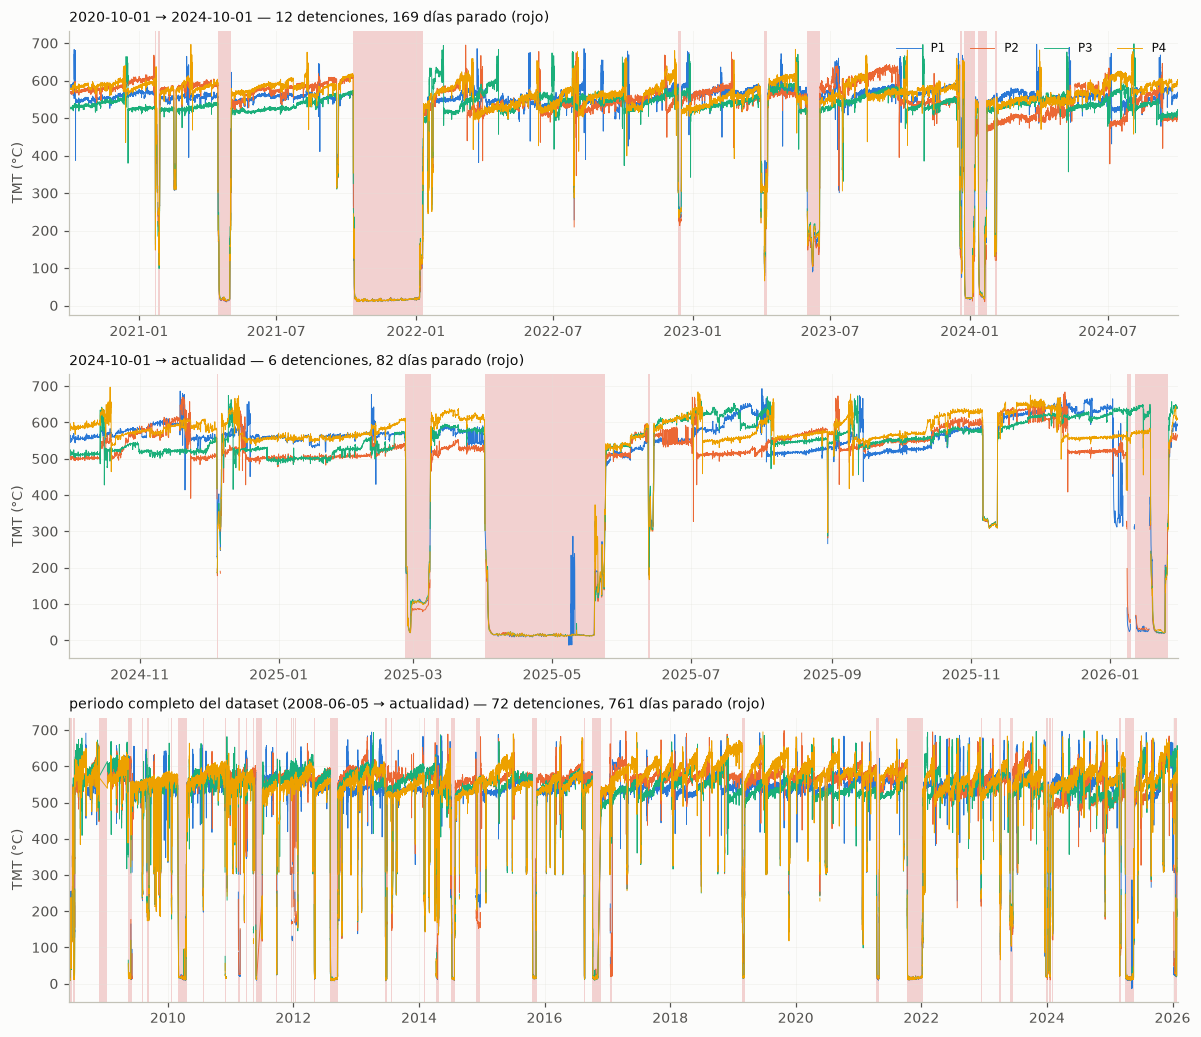

In [57]:
# temperatura mediana por paso (entre tubos válidos), a nivel horno x ts
temp_paso = (df[df.valido == 1]
             .groupby(["paso", "ts"], observed=True)["temperatura"].median()
             .unstack("paso").reindex(columns=PASOS))

ULTIMO   = df.ts.max()
PRIMERO  = horno_ts.index.min()

# ventanas de comparación reutilizadas en el resto del notebook (celdas 2, 3 y 4)
PERIODO1 = (pd.Timestamp("2020-10-01"), pd.Timestamp("2024-10-01"), "2020-10-01 → 2024-10-01")
PERIODO2 = (DATA_START,                 ULTIMO,                      f"{DATA_START.date()} → actualidad")
PERIODO3 = (PRIMERO,                    ULTIMO,                      f"periodo completo del dataset ({PRIMERO.date()} → actualidad)")
PERIODOS = [PERIODO1, PERIODO2, PERIODO3]

fig, axes = plt.subplots(len(PERIODOS), 1, figsize=(11, 9.5))

for ax, (ini, fin, titulo) in zip(axes, PERIODOS):
    vista = temp_paso.loc[ini:fin]
    for p in PASOS:
        ax.plot(vista.index, vista[p], lw=0.6, color=COLOR_PASO[p], label=p)

    ep = stops[(stops.fin >= ini) & (stops.inicio <= fin)]
    dias_parado = 0.0
    for _, r in ep.iterrows():
        a, b = max(r.inicio, ini), min(r.fin, fin)
        ax.axvspan(a, b, color="#d03b3b", alpha=0.22, lw=0)
        dias_parado += (b - a).total_seconds() / 86400

    ax.set_xlim(ini, fin)
    ax.set_ylabel("TMT (°C)")
    ax.set_title(f"{titulo} — {len(ep)} detenciones, {dias_parado:.0f} días parado (rojo)",
                 loc="left", fontsize=9)

axes[0].legend(frameon=False, ncols=4, fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(REPORTES / "graficos" / "detenciones_temperatura.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Subidas de temperatura abruptas

Rampa horaria (`ΔT` entre horas consecutivas) por tubo, calculada solo entre dos
lecturas **válidas** consecutivas (`valido==1` en ambos extremos, sin huecos) y con
el horno operando. Esto excluye los saltos falsos que produce un sensor congelado o
saturado por una sola hora (se comprobó que, sin este filtro, las rampas más grandes
del dataset son artefactos de sensor, no cambios reales de temperatura). El umbral
de "abrupta" se fija en 15 °C/h, cercano al percentil 97 de la rampa horaria en
operación sobre todo el histórico.

En vez de un conteo bruto de eventos (que favorece al periodo más largo), se compara
la **tasa** de rampas abruptas por cada 1000 h de operación entre `PERIODO1`
(2020-10-01 → 2024-10-01) y `PERIODO2` (`DATA_START` → actualidad), y la distribución
completa de rampas de cada periodo se compara en densidad (no en conteo), para que
ambos sean comparables pese a tener distinta duración.

In [58]:
tt = df.sort_values(["tubo", "ts"]).copy()
g = tt.groupby("tubo", observed=True)
tt["rampa_1h"]    = g["temperatura"].diff()
tt["valido_prev"] = g["valido"].shift()
tt["dt_h"]        = g["ts"].diff().dt.total_seconds() / 3600

valida_rampa = (tt.valido == 1) & (tt.valido_prev == 1) & (tt.dt_h == 1) & (tt.run == 1)
r = tt[valida_rampa].copy()

UMBRAL_RAMPA = 15.0   # °C/h, ~ P97 de la rampa horaria en operación (umbral redondo)

# etiqueta cada hora válida con su periodo de comparación (fuera de PERIODO1/PERIODO2 -> NaN, se descarta)
cond = [(r.ts >= PERIODO1[0]) & (r.ts < PERIODO1[1]), (r.ts >= PERIODO2[0]) & (r.ts <= PERIODO2[1])]
r["periodo"] = np.select(cond, [PERIODO1[2], PERIODO2[2]], default=None)
rp = r[r.periodo.notna()].copy()
rp["periodo"] = pd.Categorical(rp.periodo, categories=[PERIODO1[2], PERIODO2[2]], ordered=True)

abruptas = rp[rp.rampa_1h.abs() >= UMBRAL_RAMPA].copy()
abruptas["tipo"] = np.where(abruptas.rampa_1h > 0, "subida", "bajada")

resumen = pd.DataFrame({
    "horas_validas": rp.groupby("periodo", observed=True).size(),
    "n_eventos":      abruptas.groupby("periodo", observed=True).size(),
})
resumen["tasa_por_1000h"] = resumen.n_eventos / resumen.horas_validas * 1000
print(f"rampa horaria en operación (todo el histórico): P90={r.rampa_1h.abs().quantile(.90):.1f}  "
      f"P95={r.rampa_1h.abs().quantile(.95):.1f}  P99={r.rampa_1h.abs().quantile(.99):.1f} °C/h\n")
print("tasa de rampas abruptas (>= 15 °C/h) por 1000 h de operación, por periodo:")
display(resumen)

tasa_paso = (abruptas.groupby(["periodo", "paso"], observed=True).size()
             .div(rp.groupby(["periodo", "paso"], observed=True).size()) * 1000
             ).rename("eventos_1000h").unstack("periodo").reindex(index=PASOS)
print("\ntasa por paso y periodo (eventos / 1000 h operación):")
display(tasa_paso)

print("\ntop 5 subidas más pronunciadas de cada periodo:")
top_subidas = (abruptas[abruptas.tipo == "subida"]
               .sort_values("rampa_1h", ascending=False)
               .groupby("periodo", observed=True).head(5)
               .loc[:, ["periodo", "ts", "paso", "tubo", "temperatura", "rampa_1h", "h_desde_arranque"]]
               .reset_index(drop=True))
top_subidas

rampa horaria en operación (todo el histórico): P90=6.2  P95=10.0  P99=39.2 °C/h

tasa de rampas abruptas (>= 15 °C/h) por 1000 h de operación, por periodo:


,horas_validas,n_eventos,tasa_por_1000h
periodo,,,
2020-10-01 → 2024-10-01,604641,17483,28.914678
2024-10-01 → actualidad,181539,5735,31.591008



tasa por paso y periodo (eventos / 1000 h operación):


periodo,2020-10-01 → 2024-10-01,2024-10-01 → actualidad
paso,,
P1,32.198131,35.262051
P2,25.712059,33.678569
P3,25.583486,25.364652
P4,31.303249,33.338243



top 5 subidas más pronunciadas de cada periodo:


,periodo,ts,paso,tubo,temperatura,rampa_1h,h_desde_arranque
0,2020-10-01 → 2024-10-01,2021-05-02 23:00:00,P1,17D,671.944275,299.276978,35
1,2020-10-01 → 2024-10-01,2021-05-02 23:00:00,P2,18F,629.416504,292.688782,35
2,2020-10-01 → 2024-10-01,2022-10-07 18:00:00,P1,17C,648.475586,275.279785,6494
3,2020-10-01 → 2024-10-01,2021-05-02 23:00:00,P1,17E,645.640259,274.053070,35
4,2020-10-01 → 2024-10-01,2023-07-13 07:00:00,P1,17C,583.024353,268.393188,824
5,2024-10-01 → actualidad,2024-12-16 03:00:00,P2,18C,641.071838,240.030579,7548
6,2024-10-01 → actualidad,2025-11-12 12:00:00,P4,32B,553.161804,213.059906,4163
7,2024-10-01 → actualidad,2025-08-30 01:00:00,P2,18D,512.512329,208.049072,2376
8,2024-10-01 → actualidad,2025-08-30 01:00:00,P2,18E,494.954346,191.959961,2376
9,2024-10-01 → actualidad,2025-11-12 22:00:00,P1,17C,693.745972,188.062683,4173


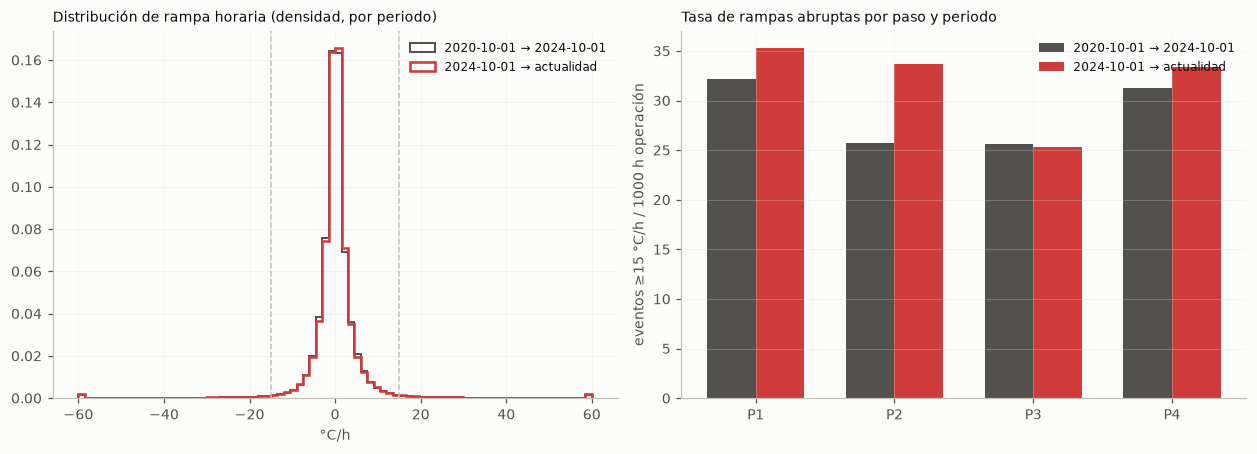

In [59]:
COLOR_PERIODO = {PERIODO1[2]: TINTA2, PERIODO2[2]: "#d03b3b"}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# A. distribución de rampa por periodo, en densidad (comparable pese a distinta duración)
ax = axes[0]
bins = np.linspace(-60, 60, 81)
for periodo in [PERIODO1[2], PERIODO2[2]]:
    d = rp.loc[rp.periodo == periodo, "rampa_1h"].clip(-60, 60)
    lw = 1.7 if periodo == PERIODO2[2] else 1.3
    ax.hist(d, bins=bins, density=True, histtype="step", lw=lw,
            color=COLOR_PERIODO[periodo], label=periodo)
ax.axvline(UMBRAL_RAMPA, color="#c3c2b7", lw=1, ls="--")
ax.axvline(-UMBRAL_RAMPA, color="#c3c2b7", lw=1, ls="--")
ax.legend(frameon=False, fontsize=8)
ax.set_xlabel("°C/h")
ax.set_title("Distribución de rampa horaria (densidad, por periodo)", loc="left", fontsize=9)

# B. tasa de eventos abruptos por paso, comparando ambos periodos
ax = axes[1]
x, w = np.arange(len(PASOS)), 0.35
ax.bar(x - w/2, tasa_paso[PERIODO1[2]], width=w, color=COLOR_PERIODO[PERIODO1[2]], label=PERIODO1[2])
ax.bar(x + w/2, tasa_paso[PERIODO2[2]], width=w, color=COLOR_PERIODO[PERIODO2[2]], label=PERIODO2[2])
ax.set_xticks(x); ax.set_xticklabels(PASOS)
ax.set_ylabel(f"eventos ≥{UMBRAL_RAMPA:.0f} °C/h / 1000 h operación")
ax.legend(frameon=False, fontsize=8)
ax.set_title("Tasa de rampas abruptas por paso y periodo", loc="left", fontsize=9)

plt.tight_layout()
plt.savefig(REPORTES / "graficos" / "rampas_abruptas.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Tiempo de saturación

`sat==1` marca horas donde el historiador clampeó la lectura por sobre `SAT_LIMITE`
(700 °C): la temperatura real pudo ser igual o mayor, pero se pierde la medición
(`temperatura` queda en NaN). Se compara el total de horas saturadas por tubo entre
`PERIODO1` (2020-10-01 → 2024-10-01) y `PERIODO2` (`DATA_START` → actualidad), y el
mapa de calor mensual se recorta a partir de 2020-10-01 (antes de eso la saturación
es prácticamente nula) con una línea vertical marcando el límite entre ambos
periodos.

In [60]:
cond = [(df.ts >= PERIODO1[0]) & (df.ts < PERIODO1[1]), (df.ts >= PERIODO2[0]) & (df.ts <= PERIODO2[1])]
df["periodo"] = np.select(cond, [PERIODO1[2], PERIODO2[2]], default=None)

dfp_run = df[(df.run == 1) & df.periodo.notna()]
sat_tubo = (dfp_run.groupby(["tubo", "periodo"], observed=True)
            .agg(h_run=("run", "size"), h_sat=("sat", "sum"))
            .assign(pct_sat=lambda d: d.h_sat / d.h_run * 100)
            .reset_index())
sat_tubo["paso"] = sat_tubo.tubo.map(TUBO_PASO)

piv_hsat = (sat_tubo.pivot(index="tubo", columns="periodo", values="h_sat")
            .reindex(columns=[PERIODO1[2], PERIODO2[2]]).fillna(0))
piv_hsat["paso"] = piv_hsat.index.map(TUBO_PASO)
piv_hsat = piv_hsat[(piv_hsat[PERIODO1[2]] > 0) | (piv_hsat[PERIODO2[2]] > 0)] \
             .sort_values(PERIODO2[2], ascending=False)

print(f"horas saturadas totales: {PERIODO1[2]} = {sat_tubo.loc[sat_tubo.periodo==PERIODO1[2],'h_sat'].sum():,} h | "
      f"{PERIODO2[2]} = {sat_tubo.loc[sat_tubo.periodo==PERIODO2[2],'h_sat'].sum():,} h")
print("\nhoras saturadas por tubo y periodo (tubos con saturación en alguno de los dos):")
display(piv_hsat)

# episodios de saturación (>=2 h), etiquetados por periodo de inicio
filas = []
for tubo, gt in df.groupby("tubo", observed=True):
    s = gt.set_index("ts")["sat"].astype(bool).sort_index()
    for a, b, h in _episodios(s, min_h=2):
        filas.append((TUBO_PASO[tubo], tubo, a, b, h))
sat_ep = pd.DataFrame(filas, columns=["paso", "tubo", "inicio", "fin", "horas"])
sat_ep["dias"] = sat_ep.horas / 24
cond_ep = [(sat_ep.inicio >= PERIODO1[0]) & (sat_ep.inicio < PERIODO1[1]),
           (sat_ep.inicio >= PERIODO2[0]) & (sat_ep.inicio <= PERIODO2[1])]
sat_ep["periodo"] = np.select(cond_ep, [PERIODO1[2], PERIODO2[2]], default="otro")

print(f"\nepisodios de saturación (>=2 h): {(sat_ep.periodo==PERIODO1[2]).sum()} en {PERIODO1[2]}, "
      f"{(sat_ep.periodo==PERIODO2[2]).sum()} en {PERIODO2[2]}")
print("\nepisodios más prolongados de cada periodo:")
sat_ep_largas = (sat_ep[sat_ep.periodo != "otro"]
                  .sort_values("horas", ascending=False)
                  .groupby("periodo", observed=True).head(8)
                  .reset_index(drop=True))
sat_ep_largas

horas saturadas totales: 2020-10-01 → 2024-10-01 = 61,768 h | 2024-10-01 → actualidad = 22,053 h

horas saturadas por tubo y periodo (tubos con saturación en alguno de los dos):


periodo,2020-10-01 → 2024-10-01,2024-10-01 → actualidad,paso
tubo,,,
32C,5,4580,P4
31B,13062,4053,P3
18F,9238,4015,P2
18D,13584,4010,P2
18B,11585,4003,P2
17C,8247,901,P1
32A,19,270,P4
32B,9,91,P4
31E,33,71,P3



episodios de saturación (>=2 h): 326 en 2020-10-01 → 2024-10-01, 161 en 2024-10-01 → actualidad

episodios más prolongados de cada periodo:


,paso,tubo,inicio,fin,horas,dias,periodo
0,P2,18F,2024-02-05 16:00:00,2024-07-02 03:00:00,3540,147.500000,2020-10-01 → 2024-10-01
1,P2,18B,2024-02-05 16:00:00,2024-07-02 01:00:00,3538,147.416667,2020-10-01 → 2024-10-01
2,P3,31C,2021-05-02 10:00:00,2021-09-04 23:00:00,3014,125.583333,2020-10-01 → 2024-10-01
3,P1,17C,2021-05-03 01:00:00,2021-08-26 04:00:00,2764,115.166667,2020-10-01 → 2024-10-01
4,P2,18D,2024-02-05 16:00:00,2024-05-28 14:00:00,2711,112.958333,2020-10-01 → 2024-10-01
5,P1,17C,2020-10-09 12:00:00,2021-01-22 13:00:00,2522,105.083333,2020-10-01 → 2024-10-01
6,P3,31B,2024-02-05 15:00:00,2024-05-08 03:00:00,2221,92.541667,2020-10-01 → 2024-10-01
7,P3,31B,2024-05-10 02:00:00,2024-08-04 13:00:00,2076,86.500000,2020-10-01 → 2024-10-01
8,P3,31B,2024-12-12 00:00:00,2025-02-25 16:00:00,1817,75.708333,2024-10-01 → actualidad
9,P2,18D,2024-12-17 12:00:00,2025-02-25 16:00:00,1685,70.208333,2024-10-01 → actualidad


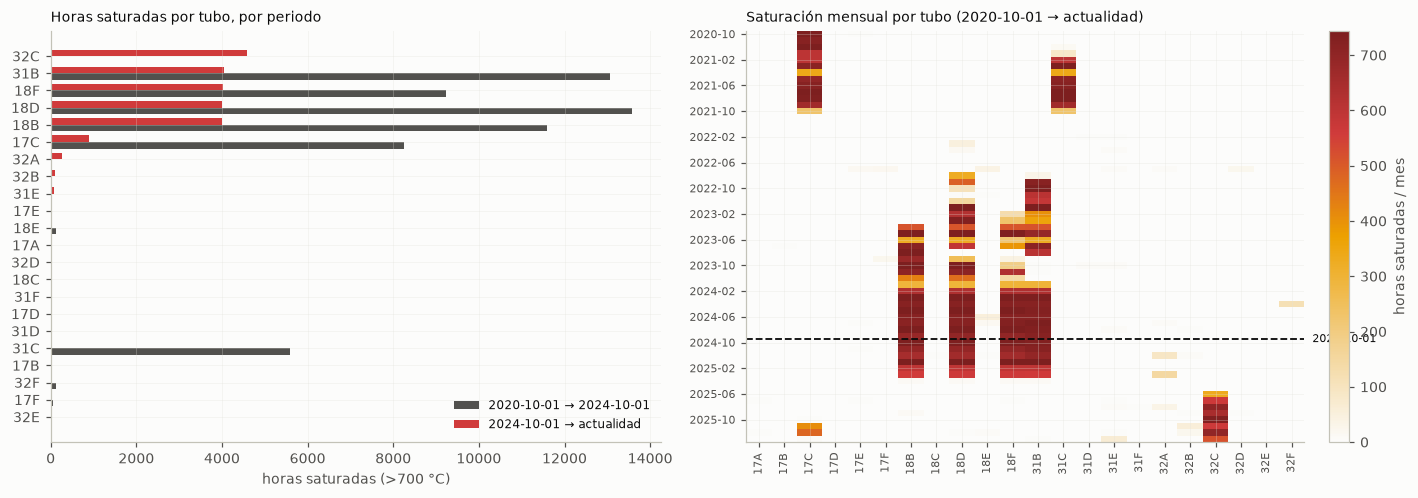

In [61]:
from matplotlib.lines import Line2D

CMAP_SAT = LinearSegmentedColormap.from_list("sat_seq", [SUP, "#f2cf8a", "#eda100", "#d03b3b", "#7d1f1f"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- horas saturadas por tubo, comparando PERIODO1 vs PERIODO2 ---
ax = axes[0]
y = np.arange(len(piv_hsat))
h = 0.38
ax.barh(y + h/2, piv_hsat[PERIODO1[2]], height=h, color=COLOR_PERIODO[PERIODO1[2]], label=PERIODO1[2])
ax.barh(y - h/2, piv_hsat[PERIODO2[2]], height=h, color=COLOR_PERIODO[PERIODO2[2]], label=PERIODO2[2])
ax.set_yticks(y); ax.set_yticklabels(piv_hsat.index)
ax.invert_yaxis()
ax.set_xlabel("horas saturadas (>700 °C)")
ax.set_title("Horas saturadas por tubo, por periodo", loc="left", fontsize=9)
ax.legend(frameon=False, fontsize=8, loc="lower right")

# --- mapa de calor: horas saturadas por tubo x mes, desde el inicio de PERIODO1 ---
ax = axes[1]
sd = df[df.ts >= PERIODO1[0]].assign(mes=lambda d: d.ts.dt.to_period("M"))
piv = (sd.groupby(["mes", "tubo"], observed=True)["sat"].sum()
         .unstack("tubo").reindex(columns=TUBOS).fillna(0))
piv = piv.loc[:, piv.sum() > 0]
im = ax.imshow(piv.values, aspect="auto", cmap=CMAP_SAT,
                extent=[0, piv.shape[1], piv.shape[0], 0])
ax.set_xticks(np.arange(piv.shape[1]) + 0.5); ax.set_xticklabels(piv.columns, fontsize=7, rotation=90)
step = max(1, piv.shape[0] // 14)
yt = np.arange(0, piv.shape[0], step)
ax.set_yticks(yt + 0.5); ax.set_yticklabels([str(piv.index[i]) for i in yt], fontsize=7)
fila_corte = (DATA_START.to_period("M") - piv.index[0]).n
ax.axhline(fila_corte, color=TINTA, lw=1.2, ls="--")
ax.text(piv.shape[1], fila_corte, f"  {PERIODO1[2].split(' → ')[1]}", fontsize=7, va="center", color=TINTA)
plt.colorbar(im, ax=ax, label="horas saturadas / mes", fraction=0.046, pad=0.04)
ax.set_title(f"Saturación mensual por tubo ({PERIODO1[0].date()} → actualidad)", loc="left", fontsize=9)

plt.tight_layout()
plt.savefig(REPORTES / "graficos" / "saturacion_horas.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Daño por creep (API 530) en el Paso 3 y su efecto en el RUL

Se aplica la extrapolación Larson-Miller de API 530 (parámetro `LMP_SIGMA`, material
T9, esfuerzo de pared `SIGMA_H` calculado en la celda 3 con la ecuación de Barlow)
para obtener `t_ruptura(T)`: las horas hasta rotura si el tubo se mantuviera todo
ese tiempo a temperatura constante `T`. La regla de acumulación de daño de Robinson
suma, hora a hora, `1/t_ruptura(T)`; el tubo falla (teóricamente) cuando la suma
`D_acum` llega a 1.

Las horas saturadas (`sat==1`, T>700 °C real desconocida) se evalúan a `SAT_LIMITE`
= 700 °C: es una **cota inferior** del daño real, porque la temperatura verdadera
pudo ser mayor. Por eso, si algo, el análisis subestima el daño en los tramos
saturados. Solo se acumula daño con el horno en operación (`run==1`); durante una
detención el tubo está frío y el consumo de vida por creep es despreciable frente al
de operación a >600 °C.

El daño se descompone en `PERIODO1` (2020-10-01 → 2024-10-01) y `PERIODO2`
(`DATA_START` → actualidad) para ver si el consumo de vida se está acelerando, y el
RUL se estima de dos formas independientes: (a) con la temperatura reciente
(P95 de los últimos 180 días) y (b) extrapolando hacia adelante la **tasa de daño
anual observada en PERIODO2** — esta segunda forma incorpora directamente el efecto
de las saturaciones prolongadas si siguieran ocurriendo al ritmo reciente.

In [62]:
def t_ruptura(T_c):
    """Horas hasta rotura a sigma_h, extrapolación iso-esfuerzo API 530 (LMP en SI)."""
    T_c = np.asarray(T_c, dtype=float)
    return 10 ** (LMP_SIGMA * 1000 / (T_c + 273.15) - CLM)

p3 = df[df.paso == "P3"].sort_values(["tubo", "ts"]).copy()
ANIOS_P1 = (PERIODO1[1] - PERIODO1[0]).days / 365.25
ANIOS_P2 = (PERIODO2[1] - PERIODO2[0]).days / 365.25

filas_creep, curvas = [], {}
for tubo, gt in p3.groupby("tubo", observed=True):
    gt = gt.sort_values("ts").set_index("ts")
    run = gt.run == 1
    T = gt.temperatura

    dano = pd.Series(0.0, index=gt.index)
    m_norm = run & T.notna()
    dano[m_norm] = 1.0 / t_ruptura(T[m_norm])
    m_sat = run & (gt.sat == 1)
    dano[m_sat] = 1.0 / t_ruptura(SAT_LIMITE)          # cota inferior: pudo ser >700 °C

    curvas[tubo] = dano.cumsum()

    D_total = dano.sum()
    D_sat   = dano[m_sat].sum()
    D_pre   = dano[dano.index < PERIODO1[0]].sum()
    D_p1    = dano[(dano.index >= PERIODO1[0]) & (dano.index < PERIODO1[1])].sum()
    D_p2    = dano[(dano.index >= PERIODO2[0]) & (dano.index <= PERIODO2[1])].sum()

    filas_creep.append((tubo, int(run.sum()), int(m_sat.sum()), D_total,
                         D_sat / D_total * 100 if D_total > 0 else 0.0,
                         D_pre, D_p1, D_p2, D_p1 / ANIOS_P1, D_p2 / ANIOS_P2))

tabla_creep = pd.DataFrame(filas_creep, columns=[
    "tubo", "h_run", "h_sat", "D_acum", "pct_dano_por_saturacion",
    "D_pre_periodo1", "D_periodo1", "D_periodo2", "tasa_anual_periodo1", "tasa_anual_periodo2"])

# RUL (a): con la carga térmica reciente (P95 en operación de los últimos 180 días)
reciente = p3[(p3.ts >= p3.ts.max() - pd.Timedelta(days=180)) & (p3.run == 1)]
T_ref = reciente.groupby("tubo", observed=True).temperatura.quantile(.95)
tabla_creep["T_ref_p95_180d"]  = tabla_creep.tubo.map(T_ref)
tabla_creep["RUL_anios_T_ref"] = (1 - tabla_creep.D_acum) * t_ruptura(tabla_creep.T_ref_p95_180d) / 8760

# RUL (b): extrapolando la tasa de daño anual observada en PERIODO2
tabla_creep["RUL_anios_tasa_periodo2"] = np.where(
    tabla_creep.tasa_anual_periodo2 > 0,
    (1 - tabla_creep.D_acum) / tabla_creep.tasa_anual_periodo2, np.inf)

tabla_creep = tabla_creep.sort_values("D_acum", ascending=False).reset_index(drop=True)

print(f"daño acumulado por tubo del Paso 3, descompuesto en antes de {PERIODO1[2].split(' → ')[0]}, "
      f"{PERIODO1[2]} y {PERIODO2[2]}, con dos estimaciones de RUL:")
tabla_creep

daño acumulado por tubo del Paso 3, descompuesto en antes de 2020-10-01, 2020-10-01 → 2024-10-01 y 2024-10-01 → actualidad, con dos estimaciones de RUL:


,tubo,h_run,h_sat,D_acum,pct_dano_por_saturacion,D_pre_periodo1,D_periodo1,D_periodo2,tasa_anual_periodo1,tasa_anual_periodo2,T_ref_p95_180d,RUL_anios_T_ref,RUL_anios_tasa_periodo2
0,31B,137836,17120,0.128066,98.346948,0.000646,9.633294e-02,0.031087,2.408323e-02,0.023363,669.687683,9.326980e+01,37.321179
1,31C,137836,5619,0.041759,98.992346,0.000430,4.127047e-02,0.000058,1.031762e-02,0.000044,587.474030,3.820595e+04,21958.185050
2,31E,137836,121,0.009254,9.619017,0.001992,4.575548e-03,0.002687,1.143887e-03,0.002019,672.634003,8.737054e+01,490.631652
3,31D,137836,19,0.003569,3.916139,0.002718,6.695196e-04,0.000182,1.673799e-04,0.000137,634.006714,1.220265e+03,7287.422939
4,31A,137836,0,0.001768,0.000000,0.001356,2.632080e-07,0.000412,6.580199e-08,0.000310,653.776428,3.094200e+02,3223.984830
5,31F,137836,14,0.000778,13.243379,0.000584,1.435226e-04,0.000050,3.588064e-05,0.000038,546.191254,1.219380e+06,26513.039819


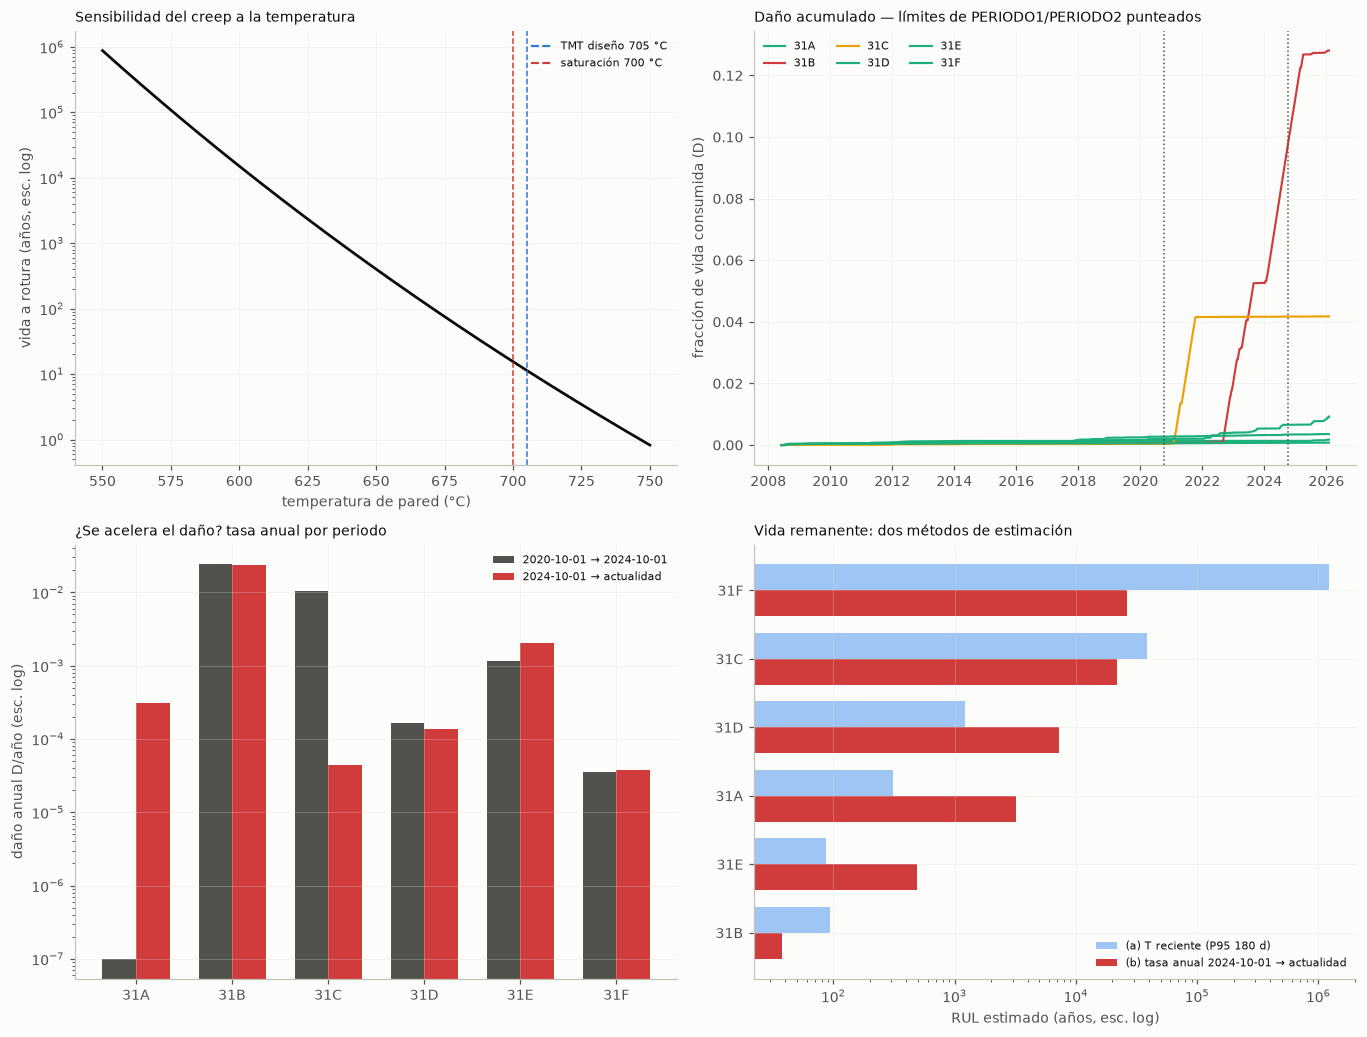

In [63]:
COLOR_TUBO_P3 = {t: ("#d03b3b" if t == tabla_creep.tubo.iloc[0] else
                      "#eda100" if t == tabla_creep.tubo.iloc[1] else
                      COLOR_PASO["P3"]) for t in TUBOS_PASO["P3"]}

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.5))

# A. sensibilidad Larson-Miller: vida a rotura vs temperatura de pared
ax = axes[0, 0]
Ts = np.linspace(550, 750, 200)
ax.semilogy(Ts, t_ruptura(Ts) / 8760, color=TINTA, lw=1.8)
ax.axvline(TMT_DISENO, color=COLOR_PASO["P1"], lw=1, ls="--")
ax.axvline(SAT_LIMITE, color="#d03b3b", lw=1, ls="--")
leyenda_a = [Line2D([], [], color=COLOR_PASO["P1"], lw=1.4, ls="--", label=f"TMT diseño {TMT_DISENO:.0f} °C"),
             Line2D([], [], color="#d03b3b", lw=1.4, ls="--", label=f"saturación {SAT_LIMITE:.0f} °C")]
ax.legend(handles=leyenda_a, frameon=False, fontsize=7, loc="upper right")
ax.set_ylabel("vida a rotura (años, esc. log)")
ax.set_xlabel("temperatura de pared (°C)")
ax.set_title("Sensibilidad del creep a la temperatura", loc="left", fontsize=9)

# B. daño acumulado (Robinson) por tubo del Paso 3, con el límite entre periodos
ax = axes[0, 1]
for tubo in TUBOS_PASO["P3"]:
    ax.plot(curvas[tubo].index, curvas[tubo].values, lw=1.4,
            color=COLOR_TUBO_P3[tubo], label=tubo)
ax.axvline(PERIODO1[0], color=TINTA2, lw=1, ls=":")
ax.axvline(PERIODO2[0], color=TINTA2, lw=1, ls=":")
ax.set_ylabel("fracción de vida consumida (D)")
ax.set_title("Daño acumulado — límites de PERIODO1/PERIODO2 punteados", loc="left", fontsize=9)
ax.legend(frameon=False, fontsize=7, ncols=3, loc="upper left")

# C. tasa de daño anual (D/año), PERIODO1 vs PERIODO2 — ¿se está acelerando?
ax = axes[1, 0]
tc = tabla_creep.set_index("tubo").reindex(TUBOS_PASO["P3"])
x, w_bar = np.arange(len(tc)), 0.35
ax.bar(x - w_bar/2, tc.tasa_anual_periodo1.clip(lower=1e-7), width=w_bar, color=COLOR_PERIODO[PERIODO1[2]], label=PERIODO1[2])
ax.bar(x + w_bar/2, tc.tasa_anual_periodo2.clip(lower=1e-7), width=w_bar, color=COLOR_PERIODO[PERIODO2[2]], label=PERIODO2[2])
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(tc.index)
ax.set_ylabel("daño anual D/año (esc. log)")
ax.legend(frameon=False, fontsize=7)
ax.set_title("¿Se acelera el daño? tasa anual por periodo", loc="left", fontsize=9)

# D. RUL: dos estimaciones independientes por tubo (esc. log)
ax = axes[1, 1]
tc2 = tabla_creep.sort_values("RUL_anios_tasa_periodo2", ascending=True)
y, h_bar = np.arange(len(tc2)), 0.38
ax.barh(y + h_bar/2, tc2.RUL_anios_T_ref, height=h_bar, color="#9ec5f4", label="(a) T reciente (P95 180 d)")
ax.barh(y - h_bar/2, tc2.RUL_anios_tasa_periodo2, height=h_bar, color=COLOR_PERIODO[PERIODO2[2]],
        label=f"(b) tasa anual {PERIODO2[2]}")
ax.set_xscale("log")
ax.set_yticks(y); ax.set_yticklabels(tc2.tubo)
ax.set_xlabel("RUL estimado (años, esc. log)")
ax.legend(frameon=False, fontsize=7, loc="lower right")
ax.set_title("Vida remanente: dos métodos de estimación", loc="left", fontsize=9)

plt.tight_layout()
plt.savefig(REPORTES / "graficos" / "creep_p3_rul.png", dpi=150, bbox_inches="tight")
plt.show()

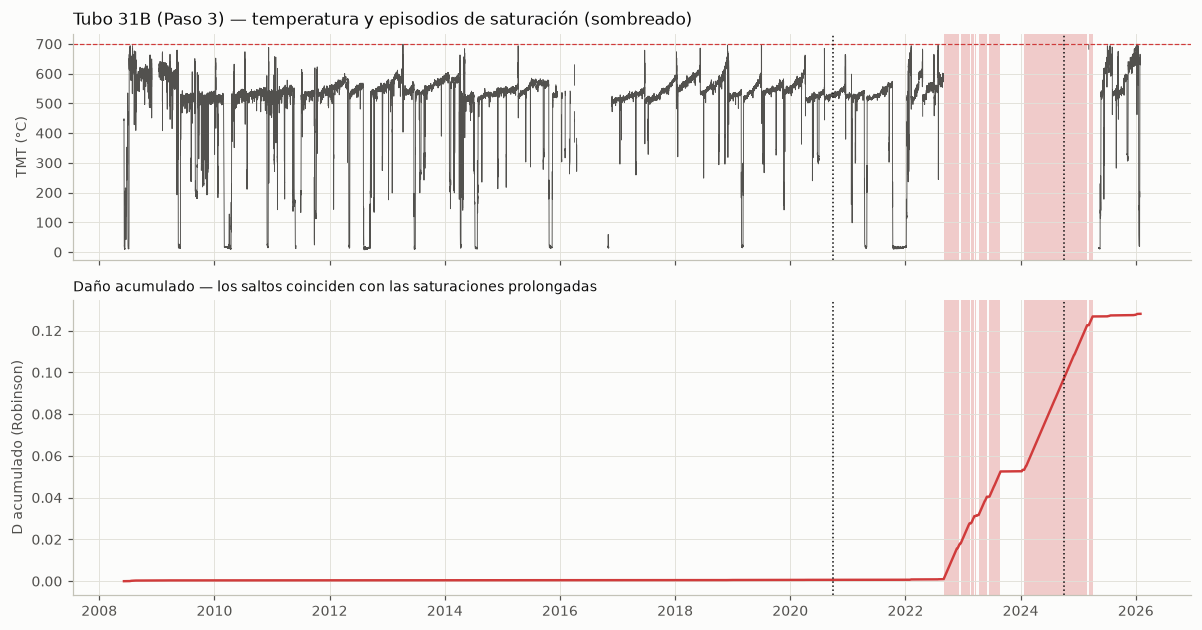

Tubo 31B: 98.3% del daño acumulado (D=0.128) proviene de horas saturadas (>700 °C), pese a representar solo 12.4% de las horas en operación.
Daño anual: 0.0241 D/año en 2020-10-01 → 2024-10-01 vs 0.0234 D/año en 2024-10-01 → actualidad (1.0x).
RUL estimado: 93.3 años con la temperatura reciente (P95 180 d), 37.3 años si se extrapola la tasa de daño de 2024-10-01 → actualidad -> ambas estimaciones muy por debajo de la mediana de los tubos del mismo paso sin saturaciones significativas -> las saturaciones prolongadas son, por lejos, el principal consumidor de vida remanente en los tubos que las sufren.


In [13]:
# --- detalle del tubo más afectado: ¿coinciden los saltos de daño con las saturaciones? ---
peor = tabla_creep.iloc[0]
g = p3[p3.tubo == peor.tubo].sort_values("ts").set_index("ts")
sat_spans = [(a, b) for a, b, h in _episodios(g["sat"].astype(bool), min_h=6)]

fig, axes = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True, height_ratios=[1, 1.3])

ax = axes[0]
ax.plot(g.index, g.temperatura, color=TINTA2, lw=0.6)
for a, b in sat_spans:
    ax.axvspan(a, b, color="#d03b3b", alpha=0.25, lw=0)
ax.axhline(SAT_LIMITE, color="#d03b3b", lw=0.8, ls="--")
ax.axvline(PERIODO1[0], color=TINTA, lw=1, ls=":")
ax.axvline(PERIODO2[0], color=TINTA, lw=1, ls=":")
ax.set_ylabel("TMT (°C)")
ax.set_title(f"Tubo {peor.tubo} (Paso 3) — temperatura y episodios de saturación (sombreado)", loc="left")

ax = axes[1]
ax.plot(curvas[peor.tubo].index, curvas[peor.tubo].values, color="#d03b3b", lw=1.6)
for a, b in sat_spans:
    ax.axvspan(a, b, color="#d03b3b", alpha=0.25, lw=0)
ax.axvline(PERIODO1[0], color=TINTA, lw=1, ls=":")
ax.axvline(PERIODO2[0], color=TINTA, lw=1, ls=":")
ax.set_ylabel("D acumulado (Robinson)")
ax.set_title("Daño acumulado — los saltos coinciden con las saturaciones prolongadas", loc="left", fontsize=9)

plt.tight_layout()
plt.savefig(REPORTES / "graficos" / f"creep_{peor.tubo}_detalle.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Tubo {peor.tubo}: {peor.pct_dano_por_saturacion:.1f}% del daño acumulado (D={peor.D_acum:.3f}) "
      f"proviene de horas saturadas (>{SAT_LIMITE:.0f} °C), pese a representar solo "
      f"{peor.h_sat/peor.h_run*100:.1f}% de las horas en operación.")
print(f"Daño anual: {peor.tasa_anual_periodo1:.4f} D/año en {PERIODO1[2]} vs "
      f"{peor.tasa_anual_periodo2:.4f} D/año en {PERIODO2[2]} "
      f"({peor.tasa_anual_periodo2/peor.tasa_anual_periodo1:.1f}x).")
print(f"RUL estimado: {peor.RUL_anios_T_ref:.1f} años con la temperatura reciente (P95 180 d), "
      f"{peor.RUL_anios_tasa_periodo2:.1f} años si se extrapola la tasa de daño de {PERIODO2[2]} "
      f"-> ambas estimaciones muy por debajo de la mediana de los tubos del mismo paso sin "
      f"saturaciones significativas -> las saturaciones prolongadas son, por lejos, el principal "
      f"consumidor de vida remanente en los tubos que las sufren.")